## Phase 2: Exploratory Data Analysis (EDA) 

##3..1 Objectives
The goal of this phase is to move beyond raw data and uncover the underlying patterns of financial behavior in Kenya. Before training our predictive models, we must understand:

- **Feature Distributions:** Identify skewness in financial variables (e.g., income) that could bias model weights.  
- **Feature-Target Relationships:** Visualize how age, education, and digital footprint differ between "High Risk" and "Low Risk" individuals.  
- **Data Quality Audit:** Detect outliers and anomalies that survived the initial cleaning phase. 2.
### 3.2 The "Credit Risk" Lens
In the context of the FinAccess 2021 dataset, we approach this EDA with specific economic hypotheses:

- **The Income Skew:** Income is expected to follow a power-law distribution, where a small number of high earners create a "long tail," necessitating transformation.  
- **The Digital Signal:** Frequent mobile money and mobile banking users may demonstrate higher financial integration, potentially correlating with lower risk.  
- **The Stability Factor:** Older respondents and those with higher formal education are expected to exhibit more stable repayment patterns.


##  1. Data preview and variable definitions

In [54]:
# we omport the libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [55]:
df=pd.read_csv('C:\\Users\\Win\\Alternative credit scoring\\Data\\cleaned_data.csv')
df.head()

,is_high_risk,A19,gender,education,B3I,incomegpnew,B3A__2,B3A__3,mobile_money_usage,mobile_bank_usage,infgp_usage,savings_usage
0,0,59.0,2.0,4.0,13000.0,5.0,1.0,0.0,1.0,3.0,1.0,1.0
1,0,43.0,2.0,4.0,6000.0,4.0,1.0,0.0,1.0,3.0,1.0,1.0
2,0,72.0,1.0,2.0,1000.0,1.0,0.0,0.0,3.0,3.0,1.0,1.0
3,0,22.0,1.0,2.0,2500.0,2.0,0.0,1.0,1.0,3.0,3.0,1.0
4,1,24.0,1.0,3.0,6000.0,4.0,1.0,0.0,1.0,1.0,1.0,1.0


In [56]:
# lets get the shape of our dataset
print(f"The shape of our dataset is:{df.shape[0]} rows and {df.shape[1]} columns")

The shape of our dataset is:19476 rows and 12 columns


In [57]:
#lets see a summary of our dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19476 entries, 0 to 19475
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   is_high_risk        19476 non-null  int64  
 1   A19                 19476 non-null  float64
 2   gender              19476 non-null  float64
 3   education           19476 non-null  float64
 4   B3I                 19476 non-null  float64
 5   incomegpnew         19476 non-null  float64
 6   B3A__2              19476 non-null  float64
 7   B3A__3              19476 non-null  float64
 8   mobile_money_usage  19476 non-null  float64
 9   mobile_bank_usage   19476 non-null  float64
 10  infgp_usage         19476 non-null  float64
 11  savings_usage       19476 non-null  float64
dtypes: float64(11), int64(1)
memory usage: 1.8 MB


In [58]:
#lets list the columns
df.columns

Index(['is_high_risk', 'A19', 'gender', 'education', 'B3I', 'incomegpnew',
       'B3A__2', 'B3A__3', 'mobile_money_usage', 'mobile_bank_usage',
       'infgp_usage', 'savings_usage'],
      dtype='object')

## 1.1 lets define the columns, as they are stated in the metadata
### Variable Definitions

| Column Name            | Variable Type              | Definition / Role |
|-----------------------|----------------------------|-------------------|
| `is_high_risk`         | Target (Binary)            | **1** if the respondent has defaulted, paid late, or experienced severe repayment distress; **0** otherwise. |
| `A19`                  | Numerical (Discrete)       | Age of the respondent. Helps determine the borrower’s lifecycle stage. |
| `gender`               | Categorical                | Biological sex of the respondent. Used to identify gender-based credit access gaps. |
| `education`            | Categorical (Ordinal)      | Highest education level completed. Proxy for human capital and long-term earning potential. |
| `B3I`                  | Numerical (Continuous)     | Monthly income in KSh. Primary indicator of repayment capacity. |
| `incomegpnew`          | Categorical                | Binned income groups, providing a normalized view of economic status. |
| `B3A__2`               | Binary Flag                | Employment income indicator. Shows whether the respondent earns a formal salary. |
| `B3A__3`               | Binary Flag                | Casual work income indicator. Captures reliance on volatile, informal labor. |
| `mobile_money_usage`   | Categorical                | Frequency of using services such as M-Pesa. Represents the respondent’s digital footprint. |
| `mobile_bank_usage`    | Categorical                | Use of banking apps (e.g., M-Shwari, KCB M-Pesa). Indicates financial sophistication. |
| `infgp_usage`          | Categorical                | Participation in Chamas or informal groups. Proxy for social collateral and reliability. |
| `savings_usage`        | Categorical                | Frequency or method of saving. Reflects financial discipline and availability of a financial buffer. |


In [59]:
#lets rename rh columns
df.rename(columns={
    'A19':'Age',
    'B3I':'Monthly_income',
    'B3A__2':'Formal_income',
    'B3A__3':'Informal_income'},inplace=True)

In [60]:
df.columns

Index(['is_high_risk', 'Age', 'gender', 'education', 'Monthly_income',
       'incomegpnew', 'Formal_income', 'Informal_income', 'mobile_money_usage',
       'mobile_bank_usage', 'infgp_usage', 'savings_usage'],
      dtype='object')

In [61]:
#lets see the statistical description of our data
# we get the statistical summary of our numericla features: Age and Income
df[['Age','Monthly_income']].describe()

,Age,Monthly_income
count,19476.000000,19476.000000
mean,39.764736,8347.476741
std,17.041139,12519.633845
min,16.000000,100.000000
25%,27.000000,3000.000000
50%,35.000000,5000.000000
75%,50.000000,10000.000000
max,116.000000,400000.000000


###  Numerical Variable Insights
A statistical summary of the continuous variables reveals the following:
* **Economic Reality:** With a median income of 5,000 KSh and a 75th percentile of 10,000 KSh, the dataset represents a low-income demographic where traditional collateral is likely unavailable.
* **Skewness Verification:** The significant gap between the Mean (8,347) and Median (5,000) for income justifies the use of Log Transformation to prevent model bias toward high-income outliers.
* **Demographic Reach:** The interquartile range for age (27–50) indicates the dataset is well-represented by the active labor force.

In [62]:
#lets check for skewness
df[['Age','Monthly_income']].skew()

Age               0.860696
Monthly_income    7.554496
dtype: float64

### Skewness Insights
* **Age (0.86):** Displays a slight right skew, reflecting Kenya's young demographic. This value is within acceptable limits for linear modeling.
* **Income (7.55):** Displays "Extreme Positive Skew." ⚡ 🤯 This indicates that a few high-income outliers dominate the mean. Without transformation, these outliers would distort the model's weight coefficients, leading to poor predictive performance for the median income bracket.

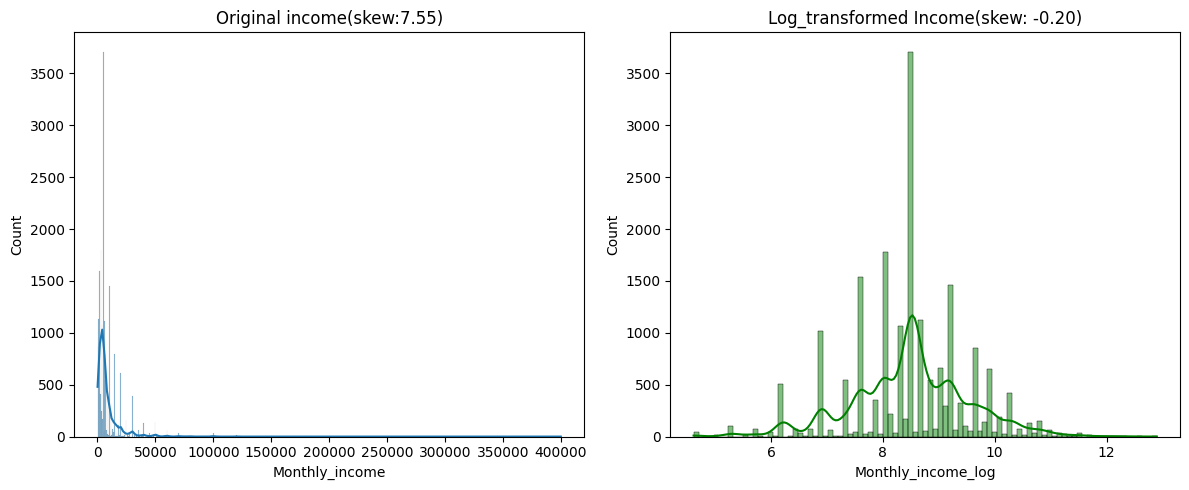

In [63]:
#having seen the skewness of the income, we opt to log_transfornm the Income column
df['Monthly_income_log'] =np.log1p(df['Monthly_income'])
#we now plot the before and after of the icome column
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df['Monthly_income'],kde=True)
plt.title(f'Original income(skew:{df['Monthly_income'].skew():.2f})')

plt.subplot(1,2,2)
sns.histplot(df['Monthly_income_log'],kde=True,color='green')
plt.title(f'Log_transformed Income(skew: {df['Monthly_income_log'].skew():.2f})')

plt.tight_layout()
plt.show()

###  Addressing Income Skewness
Our initial analysis revealed a **Skewness of 7.55** for Monthly Income (`B3I`). 
- **Observation:** This indicates a heavy right-tail distribution where extreme outliers could disproportionately influence the model's cost function.
- **Treatment:** We applied a **Natural Log Transformation** ($log(1+x)$).
- **Result:** This transformation effectively normalized the variance, ensuring that the model treats percentage changes in income (e.g., a 10% raise) consistently across different income brackets.

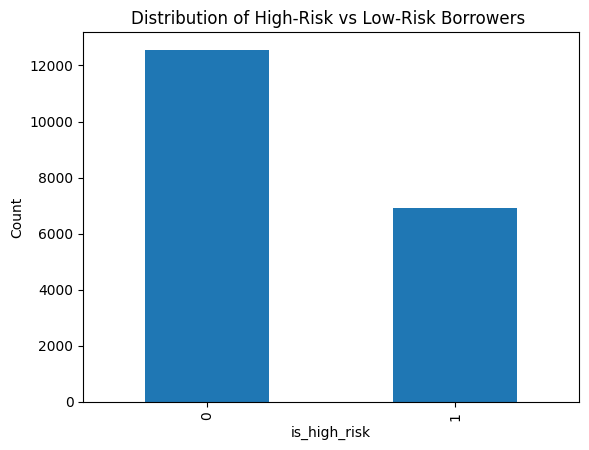

In [64]:
#lets check tha balance of risk classes
df['is_high_risk'].value_counts().plot(kind='bar')
plt.xlabel('is_high_risk')
plt.ylabel('Count')
plt.title('Distribution of High-Risk vs Low-Risk Borrowers ')
plt.show()


In [65]:
counts=df['is_high_risk'].value_counts()
percentage=df['is_high_risk'].value_counts(normalize=True)*100
print(f"Low risk(0):{counts[0]}({percentage[0]:.2f}%)")
print(f"High risk(1):{counts[1]}({percentage[1]:.2f}%)")

Low risk(0):12563(64.51%)
High risk(1):6913(35.49%)


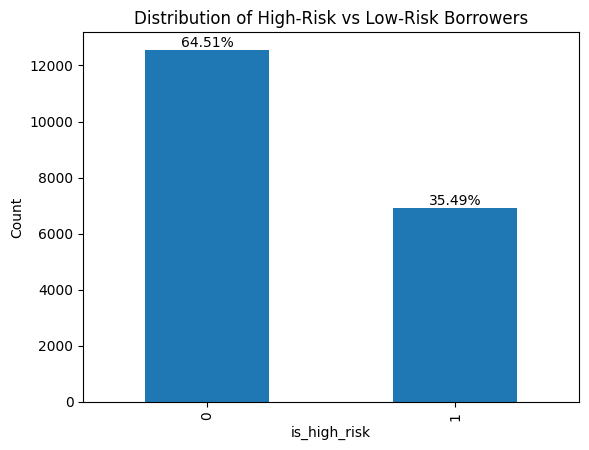

In [66]:
counts = df['is_high_risk'].value_counts()
percentages = df['is_high_risk'].value_counts(normalize=True) * 100

ax = counts.plot(kind='bar')

for i, v in enumerate(counts):
    ax.text(i, v, f"{percentages.iloc[i]:.2f}%", 
            ha='center', va='bottom')

plt.xlabel('is_high_risk')
plt.ylabel('Count')
plt.title('Distribution of High-Risk vs Low-Risk Borrowers')
plt.show()


In [67]:
df.columns

Index(['is_high_risk', 'Age', 'gender', 'education', 'Monthly_income',
       'incomegpnew', 'Formal_income', 'Informal_income', 'mobile_money_usage',
       'mobile_bank_usage', 'infgp_usage', 'savings_usage',
       'Monthly_income_log'],
      dtype='object')

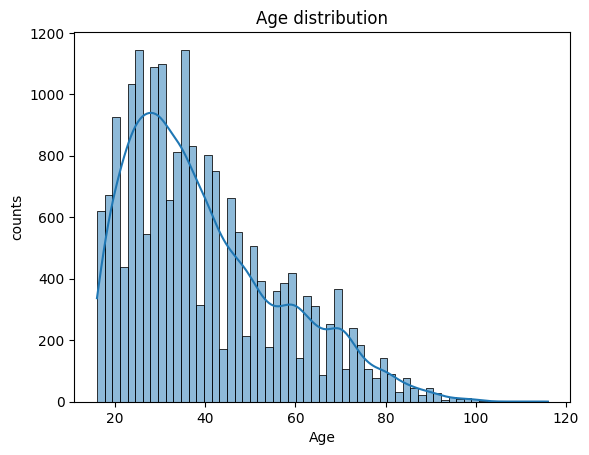

In [68]:
sns.histplot(df['Age'],kde=True)
plt.title("Age distribution")
plt.xlabel("Age")
plt.ylabel("counts")
plt.show()

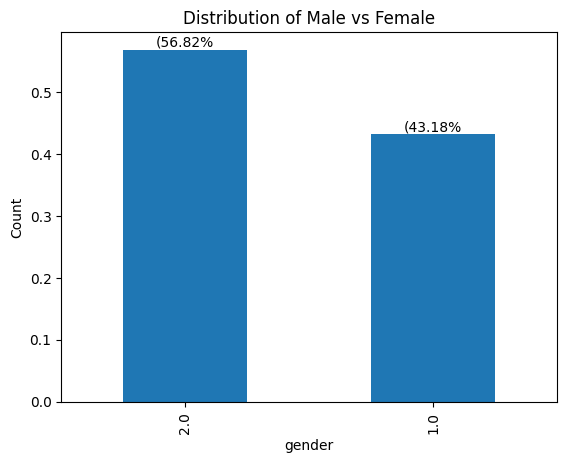

In [69]:
gender_count=df['gender'].value_counts(normalize=True)
gender_percentage=(gender_count)* 100
ax = gender_count.plot(kind='bar')
for i,v in enumerate(gender_count):
    ax.text(i,v,f"({gender_percentage.iloc[i]:.2f}%",
    ha='center',va='bottom')
plt.xlabel('gender')
plt.ylabel('Count')
plt.title('Distribution of Male vs Female')
plt.show()


In [70]:
df.columns


Index(['is_high_risk', 'Age', 'gender', 'education', 'Monthly_income',
       'incomegpnew', 'Formal_income', 'Informal_income', 'mobile_money_usage',
       'mobile_bank_usage', 'infgp_usage', 'savings_usage',
       'Monthly_income_log'],
      dtype='object')

#pairplotvisualization 
sns.pairplot(df, hue='incomegpnew')
plt.show()

# income gpnew,
formal vs informal
mobile vs bank

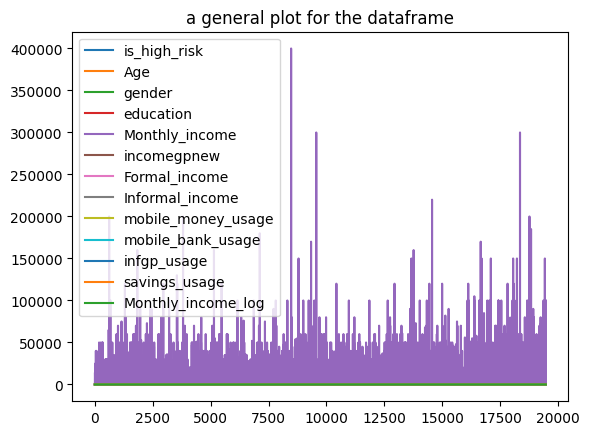

In [71]:
df.plot()
plt.title("a general plot for the dataframe")
plt.show()

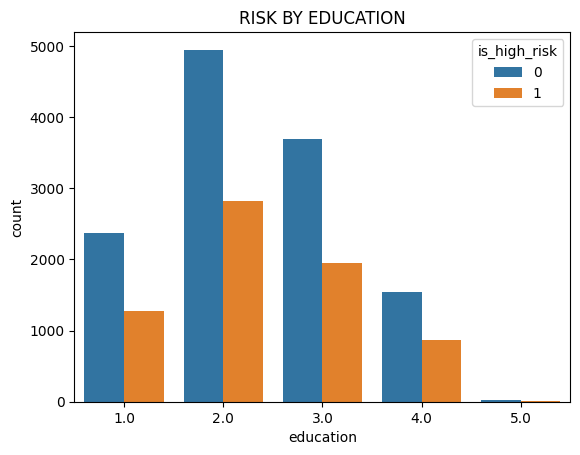

In [72]:
sns.countplot(x='education',hue='is_high_risk', data=df)
plt.title("RISK BY EDUCATION")
plt.show()

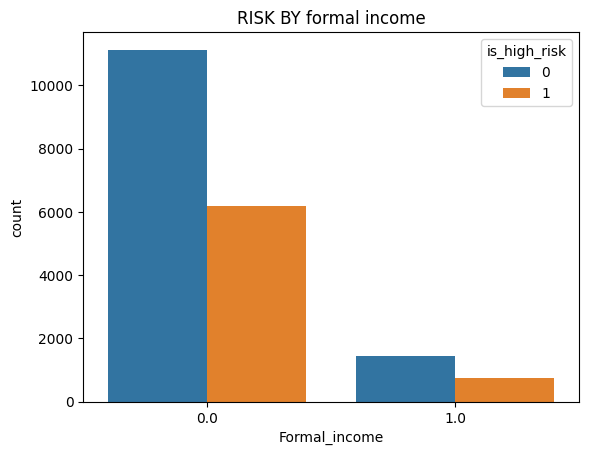

In [73]:
sns.countplot(x='Formal_income',hue='is_high_risk', data=df)
plt.title("RISK BY formal income")
plt.show()

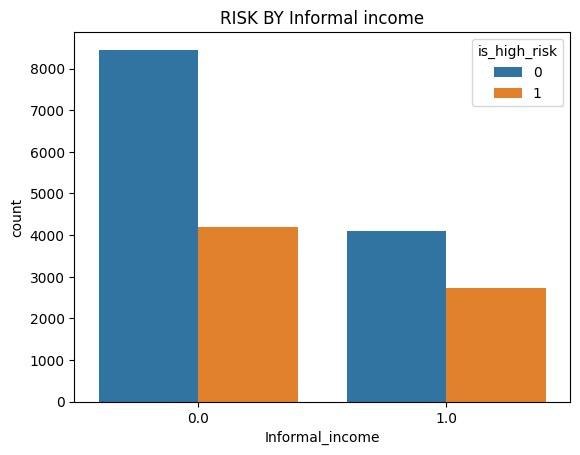

In [74]:
sns.countplot(x='Informal_income',hue='is_high_risk', data=df)
plt.title("RISK BY Informal income")
plt.show()

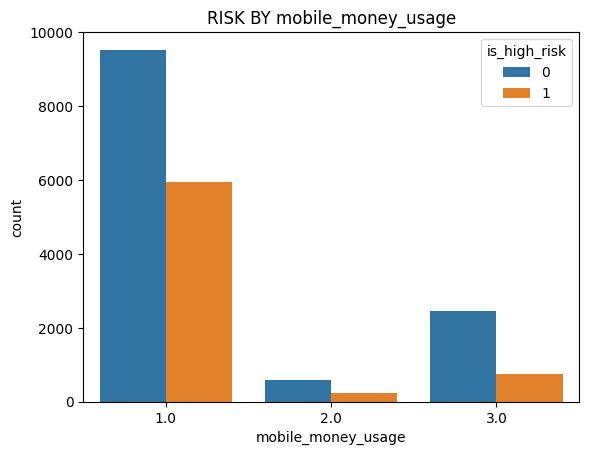

In [75]:
sns.countplot(x='mobile_money_usage',hue='is_high_risk', data=df)
plt.title("RISK BY mobile_money_usage")
plt.show()

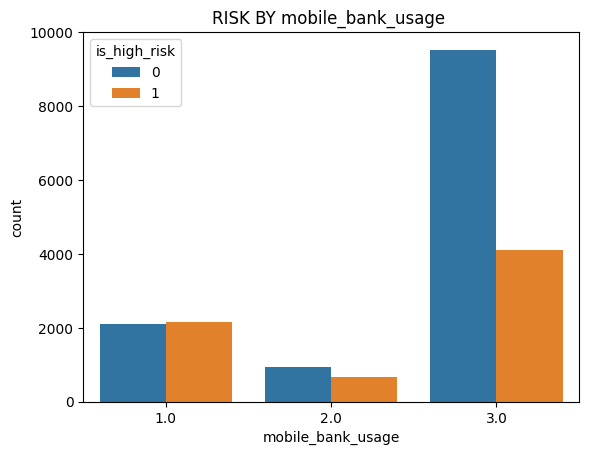

In [76]:
sns.countplot(x='mobile_bank_usage',hue='is_high_risk', data=df)
plt.title("RISK BY mobile_bank_usage ")
plt.show()

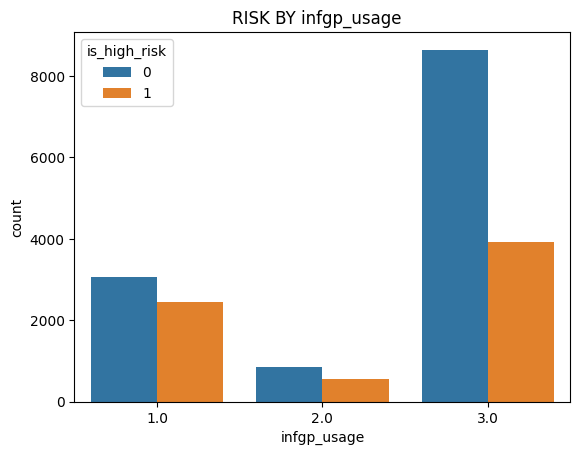

In [77]:
sns.countplot(x='infgp_usage',hue='is_high_risk', data=df)
plt.title("RISK BY infgp_usage  ")
plt.show()

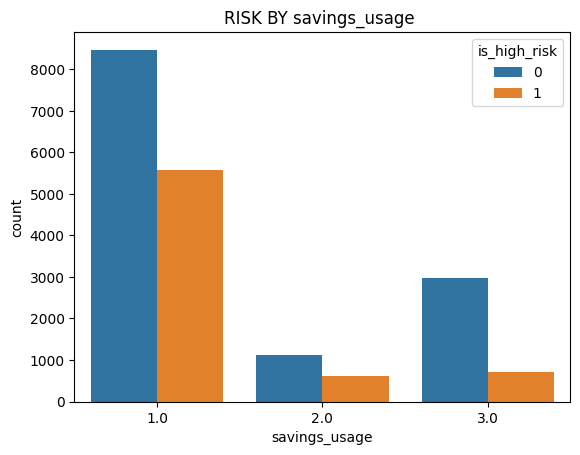

In [78]:
sns.countplot(x='savings_usage',hue='is_high_risk', data=df)
plt.title("RISK BY savings_usage ")
plt.show()

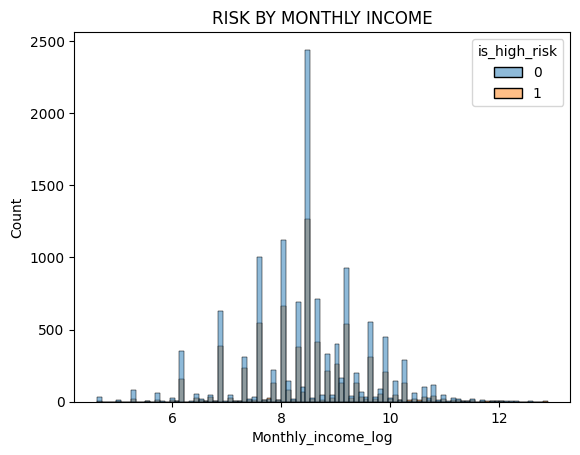

In [79]:
sns.histplot(x='Monthly_income_log',hue='is_high_risk', data=df)
plt.title("RISK BY MONTHLY INCOME")
plt.show()

In [80]:
df.corr()

,is_high_risk,Age,gender,education,Monthly_income,incomegpnew,Formal_income,Informal_income,mobile_money_usage,mobile_bank_usage,infgp_usage,savings_usage,Monthly_income_log
is_high_risk,1.000000,-0.038781,0.013165,-0.001816,-0.026777,-0.049853,-0.010980,0.067371,-0.120593,-0.179603,-0.123740,-0.159395,-0.006343
Age,-0.038781,1.000000,0.012468,-0.313127,-0.016236,0.003382,-0.077748,-0.135513,0.019524,0.134096,-0.075587,-0.016416,-0.043233
gender,0.013165,0.012468,1.000000,-0.107223,-0.144000,-0.109142,-0.097038,-0.108990,0.055841,0.076017,-0.171504,0.011038,-0.190301
education,-0.001816,-0.313127,-0.107223,1.000000,0.272812,0.150087,0.287062,-0.026996,-0.243022,-0.354827,-0.101121,-0.191633,0.259131
Monthly_income,-0.026777,-0.016236,-0.144000,0.272812,1.000000,0.390918,0.342139,-0.119594,-0.162646,-0.198418,-0.060201,-0.107720,0.704923
incomegpnew,-0.049853,0.003382,-0.109142,0.150087,0.390918,1.000000,0.181574,-0.093108,-0.129931,-0.128172,0.009728,-0.044818,0.618406
Formal_income,-0.010980,-0.077748,-0.097038,0.287062,0.342139,0.181574,1.000000,-0.220432,-0.135356,-0.194662,-0.050082,-0.116917,0.339858
Informal_income,0.067371,-0.135513,-0.108990,-0.026996,-0.119594,-0.093108,-0.220432,1.000000,-0.045259,0.006874,0.016908,0.002766,-0.076958
mobile_money_usage,-0.120593,0.019524,0.055841,-0.243022,-0.162646,-0.129931,-0.135356,-0.045259,1.000000,0.287168,0.200863,0.366707,-0.283118
mobile_bank_usage,-0.179603,0.134096,0.076017,-0.354827,-0.198418,-0.128172,-0.194662,0.006874,0.287168,1.000000,0.182589,0.246891,-0.250262


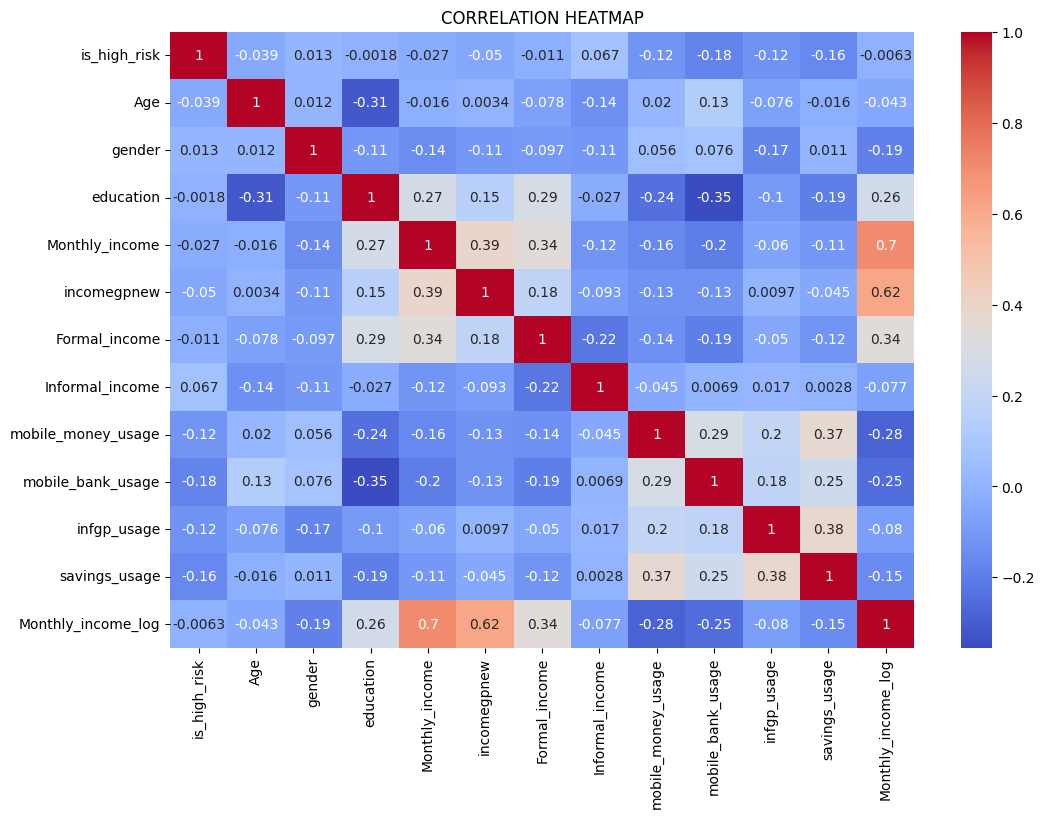

In [81]:
#CORRELATION HEATMAP
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("CORRELATION HEATMAP")
plt.show()

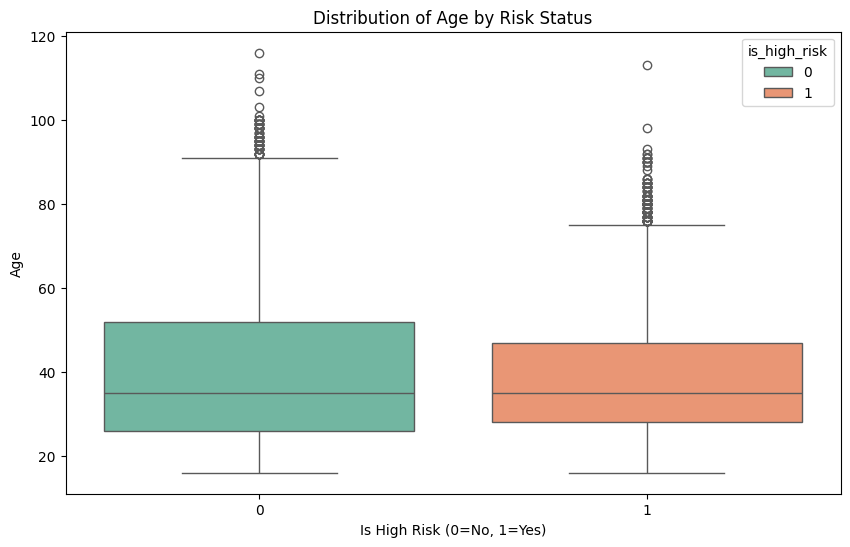

In [82]:
# 1. Age vs. Risk
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='is_high_risk', y='Age',hue='is_high_risk', palette='Set2')
plt.title('Distribution of Age by Risk Status')
plt.xlabel('Is High Risk (0=No, 1=Yes)')
plt.ylabel('Age')
plt.show()


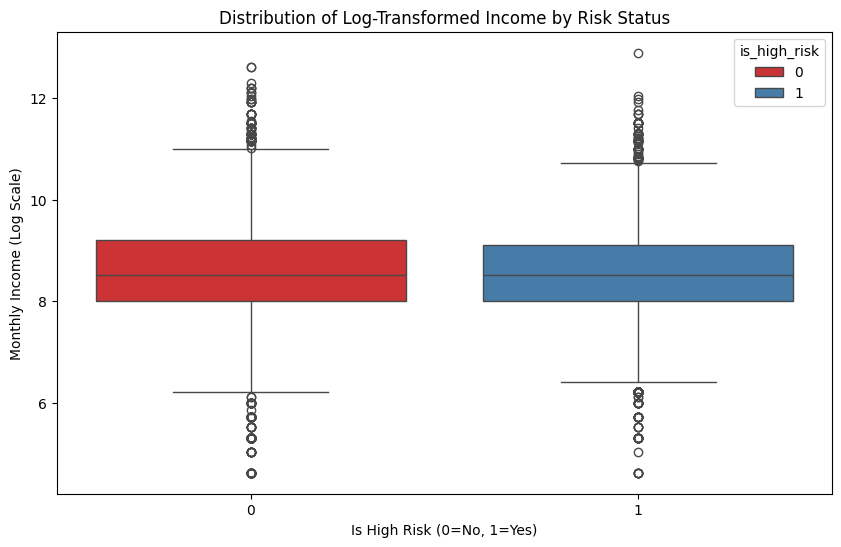

In [83]:
# 2. Log-Transformed Income vs. Risk
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='is_high_risk', y='Monthly_income_log',hue='is_high_risk', palette='Set1')
plt.title('Distribution of Log-Transformed Income by Risk Status')
plt.xlabel('Is High Risk (0=No, 1=Yes)')
plt.ylabel('Monthly Income (Log Scale)')
plt.show()

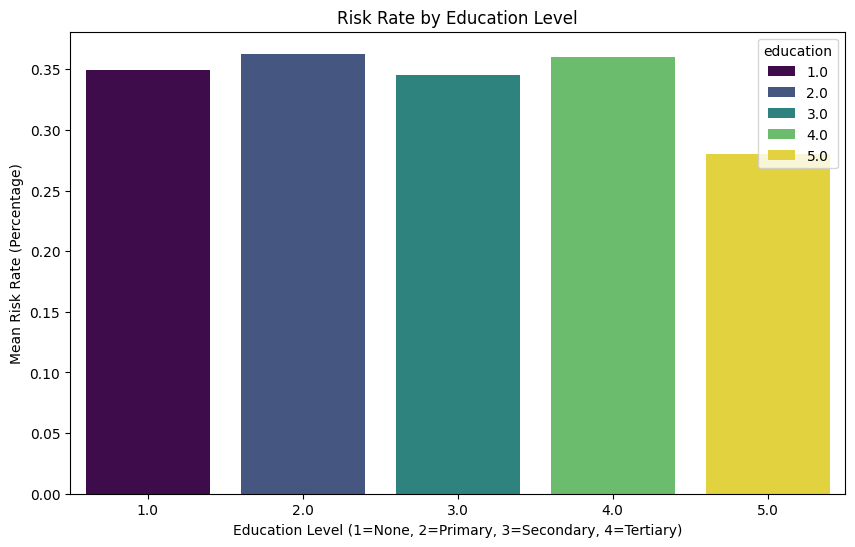

In [84]:
# 3. Education Level vs. Risk Rate
# Calculate the mean of 'is_high_risk' per education category (which equals the risk %)
edu_risk = df.groupby('education')['is_high_risk'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=edu_risk, x='education', y='is_high_risk',hue='education',palette='viridis')
plt.title('Risk Rate by Education Level')
plt.xlabel('Education Level (1=None, 2=Primary, 3=Secondary, 4=Tertiary)')
plt.ylabel('Mean Risk Rate (Percentage)')
plt.show()


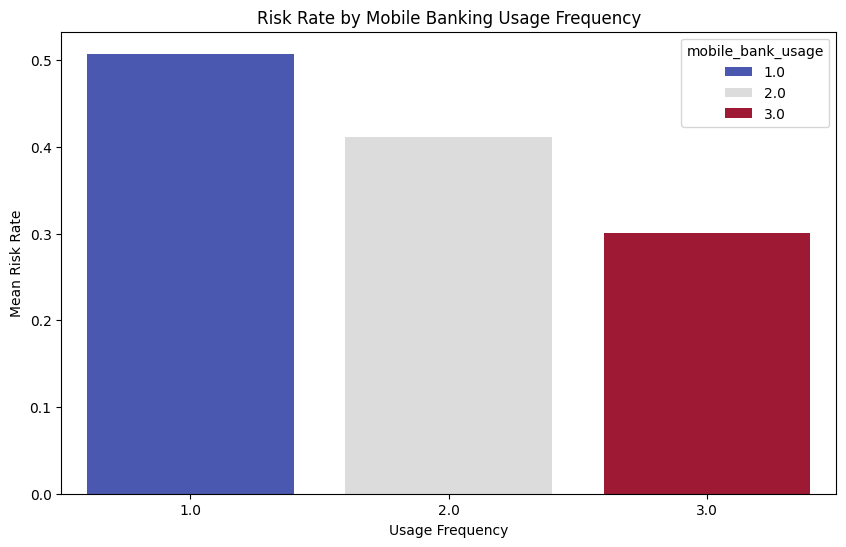

In [85]:
# 4. Mobile Banking Usage vs. Risk Rate
mb_risk = df.groupby('mobile_bank_usage')['is_high_risk'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=mb_risk, x='mobile_bank_usage', y='is_high_risk',hue='mobile_bank_usage', palette='coolwarm')
plt.title('Risk Rate by Mobile Banking Usage Frequency')
plt.xlabel('Usage Frequency')
plt.ylabel('Mean Risk Rate')
plt.show()

In [86]:
# 1. Cap the Age at 95
# This keeps everyone's data but changes any value > 95 to exactly 95
df['Age'] = df['Age'].clip(upper=95)
print(f"Age capping complete. New Max Age: {df['Age'].max()}")


Age capping complete. New Max Age: 95.0


In [87]:
df_encoded=pd.read_csv('C:\\Users\\Win\\Alternative credit scoring\\Data\\encoded_data.csv')
df_encoded.head()

,A19,B3I,gender_2.0,education_2.0,education_3.0,education_4.0,education_5.0,incomegpnew_2.0,incomegpnew_3.0,incomegpnew_4.0,...,B3A__3_1.0,mobile_money_usage_2.0,mobile_money_usage_3.0,mobile_bank_usage_2.0,mobile_bank_usage_3.0,infgp_usage_2.0,infgp_usage_3.0,savings_usage_2.0,savings_usage_3.0,is_high_risk_target
0,59.0,13000.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0
1,43.0,6000.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0
2,72.0,1000.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0
3,22.0,2500.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0
4,24.0,6000.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


In [88]:
df_encoded.columns

Index(['A19', 'B3I', 'gender_2.0', 'education_2.0', 'education_3.0',
       'education_4.0', 'education_5.0', 'incomegpnew_2.0', 'incomegpnew_3.0',
       'incomegpnew_4.0', 'incomegpnew_5.0', 'incomegpnew_6.0',
       'incomegpnew_7.0', 'incomegpnew_8.0', 'incomegpnew_9.0',
       'incomegpnew_10.0', 'B3A__2_1.0', 'B3A__3_1.0',
       'mobile_money_usage_2.0', 'mobile_money_usage_3.0',
       'mobile_bank_usage_2.0', 'mobile_bank_usage_3.0', 'infgp_usage_2.0',
       'infgp_usage_3.0', 'savings_usage_2.0', 'savings_usage_3.0',
       'is_high_risk_target'],
      dtype='object')

In [89]:
df.columns

Index(['is_high_risk', 'Age', 'gender', 'education', 'Monthly_income',
       'incomegpnew', 'Formal_income', 'Informal_income', 'mobile_money_usage',
       'mobile_bank_usage', 'infgp_usage', 'savings_usage',
       'Monthly_income_log'],
      dtype='object')

In [90]:
# 1. Cap the Age at 95
# This keeps everyone's data but changes any value > 95 to exactly 95
df_encoded['A19'] = df_encoded['A19'].clip(upper=95)
print(f"Age capping complete. New Max Age: {df_encoded['A19'].max()}")


Age capping complete. New Max Age: 95.0


In [91]:
df_encoded['B3I_log'] = df['Monthly_income_log']

In [92]:
# 2. Select key columns for the Heatmap 
# (Including all one-hot encoded columns makes the map unreadable, 
# so we focus on the main drivers and the target)
key_cols = ['is_high_risk_target', 'A19', 'B3I_log', 'gender_2.0', 'education_4.0', 'mobile_bank_usage_3.0']
corr_matrix = df_encoded[key_cols].corr()

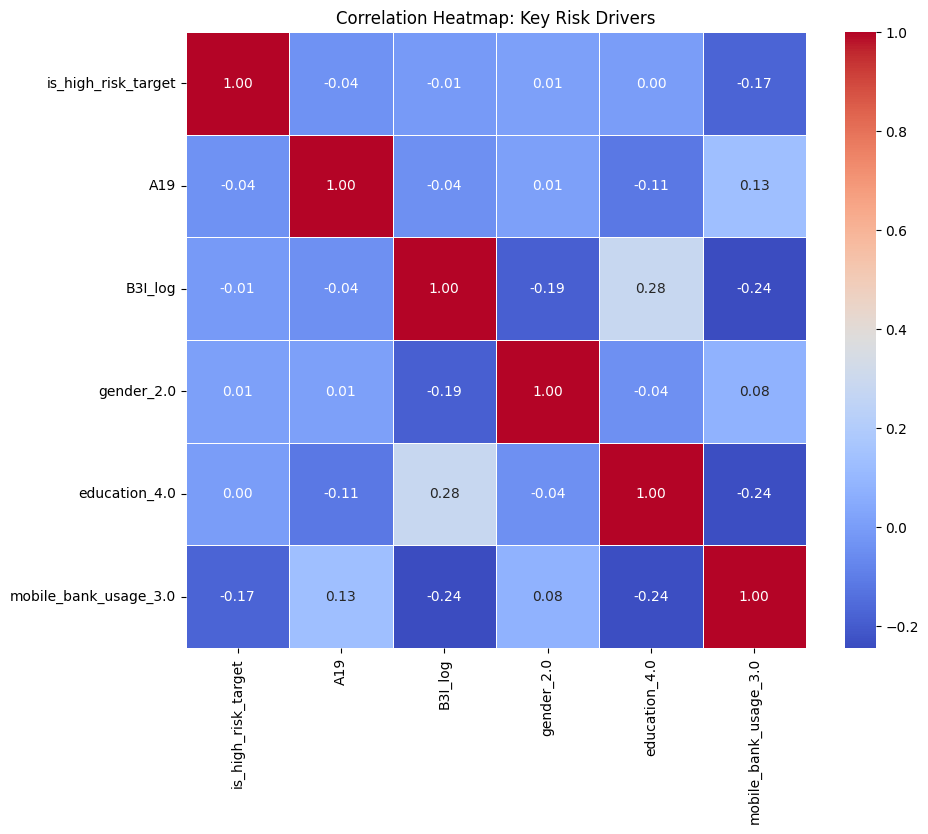

In [93]:
# 3. Plot the Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap: Key Risk Drivers')
plt.show()


In [94]:
df_encoded['B3I'].max()

400000.0

In [95]:
df_encoded.isnull().sum()

A19                       0
B3I                       0
gender_2.0                0
education_2.0             0
education_3.0             0
education_4.0             0
education_5.0             0
incomegpnew_2.0           0
incomegpnew_3.0           0
incomegpnew_4.0           0
incomegpnew_5.0           0
incomegpnew_6.0           0
incomegpnew_7.0           0
incomegpnew_8.0           0
incomegpnew_9.0           0
incomegpnew_10.0          0
B3A__2_1.0                0
B3A__3_1.0                0
mobile_money_usage_2.0    0
mobile_money_usage_3.0    0
mobile_bank_usage_2.0     0
mobile_bank_usage_3.0     0
infgp_usage_2.0           0
infgp_usage_3.0           0
savings_usage_2.0         0
savings_usage_3.0         0
is_high_risk_target       0
B3I_log                   0
dtype: int64

In [102]:
df_encoded=df_encoded.drop("B3I",axis=1)

In [103]:
df_encoded.columns

Index(['A19', 'gender_2.0', 'education_2.0', 'education_3.0', 'education_4.0',
       'education_5.0', 'incomegpnew_2.0', 'incomegpnew_3.0',
       'incomegpnew_4.0', 'incomegpnew_5.0', 'incomegpnew_6.0',
       'incomegpnew_7.0', 'incomegpnew_8.0', 'incomegpnew_9.0',
       'incomegpnew_10.0', 'B3A__2_1.0', 'B3A__3_1.0',
       'mobile_money_usage_2.0', 'mobile_money_usage_3.0',
       'mobile_bank_usage_2.0', 'mobile_bank_usage_3.0', 'infgp_usage_2.0',
       'infgp_usage_3.0', 'savings_usage_2.0', 'savings_usage_3.0',
       'is_high_risk_target', 'B3I_log'],
      dtype='object')

In [106]:
#we save the dataset, that we have log transformed the income, and cappsd the age
df_encoded.to_csv("C:\\Users\\Win\\Alternative credit scoring\\Data\\Modelling_data.csv",index=False)

In [ ]:
## ENDS EDA
### NEXT: MODELLING